# 本分析は、CKD重症化予防のための介入対象特定を目的とする。

## 仮説立て

- 透析患者は高齢化が進んでいる、加齢も慢性腎不全の因子の一つと言われているが果たして本当か？高齢化社会で病気の人の年齢が上がっただけでは？
- 慢性腎不全の代表的因子は糖尿病と高血圧だが、どっちの因子が強い？
- 若年の慢性腎不全の特徴は？

## 必要なライブラリのインポート

In [159]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu, chi2_contingency, fisher_exact

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

## データの読み込み

In [160]:
arff_path = "/content/chronic_kidney_disease.arff"

with open(arff_path, "r", encoding="utf-8") as f:
    lines = f.readlines()

columns = []
for line in lines:
    line = line.strip()
    if line.lower().startswith("@attribute"):
        columns.append(line.split()[1].replace("'", "").replace('"', ""))

data_start = [i for i, line in enumerate(lines) if line.strip().lower() == "@data"][0]
data_lines = lines[data_start + 1:]

clean_rows = []

for line in data_lines:
    line = line.strip()
    if line == "" or line.startswith("%"):
        continue

    values = [v.strip() for v in line.split(",")]

    if len(values) > len(columns):
        values = values[:len(columns)]

    if len(values) < len(columns):
        values += ["?"] * (len(columns) - len(values))

    clean_rows.append(values)

df = pd.DataFrame(clean_rows, columns=columns)

df = df.replace("?", pd.NA)

df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48,80,1.020,1,0,<NA>,normal,notpresent,notpresent,121,36,1.2,<NA>,<NA>,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7,50,1.020,4,0,<NA>,normal,notpresent,notpresent,<NA>,18,0.8,<NA>,<NA>,11.3,38,6000,<NA>,no,no,no,good,no,no,ckd
2,62,80,1.010,2,3,normal,normal,notpresent,notpresent,423,53,1.8,<NA>,<NA>,9.6,31,7500,<NA>,no,yes,no,poor,no,yes,ckd
3,48,70,1.005,4,0,normal,abnormal,present,notpresent,117,56,3.8,111,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51,80,1.010,2,0,normal,normal,notpresent,notpresent,106,26,1.4,<NA>,<NA>,11.6,35,7300,4.6,no,no,no,good,no,no,ckd


## EDA1

In [161]:
# 400行25列であることを確認
df.shape

(400, 25)

In [162]:
# 欠損値の確認 全データobject型であることを確認
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   age     391 non-null    object
 1   bp      388 non-null    object
 2   sg      353 non-null    object
 3   al      354 non-null    object
 4   su      351 non-null    object
 5   rbc     248 non-null    object
 6   pc      335 non-null    object
 7   pcc     396 non-null    object
 8   ba      396 non-null    object
 9   bgr     356 non-null    object
 10  bu      381 non-null    object
 11  sc      383 non-null    object
 12  sod     313 non-null    object
 13  pot     312 non-null    object
 14  hemo    348 non-null    object
 15  pcv     329 non-null    object
 16  wbcc    294 non-null    object
 17  rbcc    269 non-null    object
 18  htn     398 non-null    object
 19  dm      398 non-null    object
 20  cad     398 non-null    object
 21  appet   399 non-null    object
 22  pe      399 non-null    ob

In [163]:
# 各列,欠損値の合計確認
df.isnull().sum()

,0
age,9
bp,12
sg,47
al,46
su,49
rbc,152
pc,65
pcc,4
ba,4
bgr,44


## EDA2前のデータ前処理1

In [164]:
# 数値データobject -> floatに変換
df = df.apply(lambda col: pd.to_numeric(col, errors='ignore'))

/tmp/ipykernel_24360/4011106024.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(lambda col: pd.to_numeric(col, errors='ignore'))


In [165]:
# object数値データ -> float64数値データ 確認する
df.dtypes

,0
age,float64
bp,float64
sg,float64
al,float64
su,float64
rbc,object
pc,object
pcc,object
ba,object
bgr,float64


In [166]:
# 重複行の確認
df.duplicated(keep=False).value_counts() # 重複行なし

,count
False,400


In [167]:
# float64データを確認
df.select_dtypes(include='float64')

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc
0,48.0,80.0,1.020,1.0,0.0,121.0,36.0,1.2,NaN,NaN,15.4,44.0,7800.0,5.2
1,7.0,50.0,1.020,4.0,0.0,NaN,18.0,0.8,NaN,NaN,11.3,38.0,6000.0,NaN
2,62.0,80.0,1.010,2.0,3.0,423.0,53.0,1.8,NaN,NaN,9.6,31.0,7500.0,NaN
3,48.0,70.0,1.005,4.0,0.0,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9
4,51.0,80.0,1.010,2.0,0.0,106.0,26.0,1.4,NaN,NaN,11.6,35.0,7300.0,4.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,140.0,49.0,0.5,150.0,4.9,15.7,47.0,6700.0,4.9
396,42.0,70.0,1.025,0.0,0.0,75.0,31.0,1.2,141.0,3.5,16.5,54.0,7800.0,6.2
397,12.0,80.0,1.020,0.0,0.0,100.0,26.0,0.6,137.0,4.4,15.8,49.0,6600.0,5.4
398,17.0,60.0,1.025,0.0,0.0,114.0,50.0,1.0,135.0,4.9,14.2,51.0,7200.0,5.9


In [168]:
# objectデータを確認
df_obj = df.select_dtypes(include='object')
df_obj

,rbc,pc,pcc,ba,htn,dm,cad,appet,pe,ane,class
0,<NA>,normal,notpresent,notpresent,yes,yes,no,good,no,no,ckd
1,<NA>,normal,notpresent,notpresent,no,no,no,good,no,no,ckd
2,normal,normal,notpresent,notpresent,no,yes,no,poor,no,yes,ckd
3,normal,abnormal,present,notpresent,yes,no,no,poor,yes,yes,ckd
4,normal,normal,notpresent,notpresent,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...
395,normal,normal,notpresent,notpresent,no,no,no,good,no,no,notckd
396,normal,normal,notpresent,notpresent,no,no,no,good,no,no,notckd
397,normal,normal,notpresent,notpresent,no,no,no,good,no,no,notckd
398,normal,normal,notpresent,notpresent,no,no,no,good,no,no,notckd


In [169]:
# それぞれの列のユニークな値の数を確認
df_uni = df_obj.nunique()
df_uni

,0
rbc,2
pc,2
pcc,2
ba,2
htn,2
dm,3
cad,2
appet,3
pe,3
ane,2


In [170]:
# 各列のユニークな値
for uni in df_obj.columns:
    print(uni)
    print(df_obj[uni].unique())

# dm -> ['yes' 'no' <NA> ''] <NA>,'' の空白の表記ゆれ確認

# appet -> ['good' 'poor' <NA> 'no'] 'poor'と'no'の表記ゆれ？確認

# pe -> ['no' 'yes' <NA> 'good'] 'yes'と'good'の表記ゆれ？確認

# class -> ['ckd' 'notckd' 'no'] 'notckd'と'no'の表記ゆれ？確認

rbc
[<NA> 'normal' 'abnormal']
pc
['normal' 'abnormal' <NA>]
pcc
['notpresent' 'present' <NA>]
ba
['notpresent' 'present' <NA>]
htn
['yes' 'no' <NA>]
dm
['yes' 'no' <NA> '']
cad
['no' 'yes' <NA>]
appet
['good' 'poor' <NA> 'no']
pe
['no' 'yes' <NA> 'good']
ane
['no' 'yes' <NA>]
class
['ckd' 'notckd' 'no']


In [171]:
# 上記の表記ゆれ補正の前に
# カラム名 [''dm''] の表記を ['dm'] に変更
df.columns

Index(['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'class'],
      dtype='object')

In [172]:
# カラム名を変換
df.columns = (
    df.columns
    .str.replace("`", "", regex=False)
    .str.replace("'", "", regex=False)
    .str.replace('"', "", regex=False)
    .str.strip()
)

In [173]:
# カラム名の変換を確認
df.columns

Index(['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu',
       'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'class'],
      dtype='object')

In [174]:
# 各カラムの「正しい値（定義）」を設定
valid_values = {
    'dm': ['yes', 'no'],
    'htn': ['yes', 'no'],
    'cad': ['yes', 'no'],
    'pe': ['yes', 'no'],
    'ane': ['yes', 'no'],
    'appet': ['good', 'poor'],
    'class': ['ckd', 'notckd']
}

# 定義外データのカウント
for col, valid in valid_values.items():
    invalid_count = (~df[col].isin(valid) & df[col].notna()).sum()
    print(f"{col}: 定義外データ数 = {invalid_count}")

dm: 定義外データ数 = 1
htn: 定義外データ数 = 0
cad: 定義外データ数 = 0
pe: 定義外データ数 = 1
ane: 定義外データ数 = 0
appet: 定義外データ数 = 1
class: 定義外データ数 = 1


- dm -> ['yes','no','NA','']でNAと'' の表記ゆれ確認 -> 明確に欠損値の表記ゆれであることを解釈できる。

- appet -> ['good','poor','NA','no'] で'poor'と'no'の表記ゆれ？ -> appetは食欲という意味で'poor'は食欲不振と解釈できる。'no'も食欲不振と解釈？だが断定はできない、欠損値か？

- pe -> ['no','yes','NA','good'] で'no'と'good'の表記ゆれ？ -> peは足の浮腫で'no'は浮腫(-)と解釈できる。'good'も浮腫(-)と解釈？

- class -> ['ckd','notckd','no'] で'notckd'と'no'の表記ゆれ？ -> classは目的変数であり、notckdは「慢性腎不全ではない」と解釈できる。'no'はnotckdと同等か欠損値？

- **dmは'NA'と' 'は'NA'でまとめる。**
- **appetの'no'は'NA'に変換する。**
- **peの'good'は念のため'NA'に変換する**
- **classの'no'は'NA'に変換する**

- 意味を無理に解釈しない
- 定義外は欠損扱い
- ターゲットは慎重に扱う

In [175]:
# 空文字を欠損に統一
df = df.replace('', pd.NA)

# dm（NA統一）
df['dm'] = df['dm'].replace('NA', pd.NA)

# appet（定義外 -> NA）
df['appet'] = df['appet'].where(df['appet'].isin(['good','poor']), pd.NA)

# pe（定義外 -> NA）
df['pe'] = df['pe'].where(df['pe'].isin(['yes','no']), pd.NA)

# class（定義外 -> NA）
df['class'] = df['class'].where(df['class'].isin(['ckd','notckd']), pd.NA)

In [176]:
# objectを確認
df_obj = df.select_dtypes(include='object')

# 各列のユニークな値
# 変換OK
for uni in df_obj.columns:
    print(uni)
    print(df_obj[uni].unique())

rbc
[<NA> 'normal' 'abnormal']
pc
['normal' 'abnormal' <NA>]
pcc
['notpresent' 'present' <NA>]
ba
['notpresent' 'present' <NA>]
htn
['yes' 'no' <NA>]
dm
['yes' 'no' <NA>]
cad
['no' 'yes' <NA>]
appet
['good' 'poor' <NA>]
pe
['no' 'yes' <NA>]
ane
['no' 'yes' <NA>]
class
['ckd' 'notckd' <NA>]


In [177]:
# 2値カテゴリを 0/1 に変換
# Label Encodingを行う

binary_map = {
    "normal": 0,
    "abnormal": 1,
    "notpresent": 0,
    "present": 1,
    "no": 0,
    "yes": 1,
    "good": 0,
    "poor": 1,
    "notckd": 0,
    "ckd": 1
}

# 解釈しやすいように 1を「リスク側・異常側」に寄せる。

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].map(binary_map)

df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,0.0,0.0,0.0,121.0,36.0,1.2,NaN,NaN,15.4,44.0,7800.0,5.2,1.0,1.0,0.0,0.0,0.0,0.0,1.0
1,7.0,50.0,1.020,4.0,0.0,NaN,0.0,0.0,0.0,NaN,18.0,0.8,NaN,NaN,11.3,38.0,6000.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,62.0,80.0,1.010,2.0,3.0,0.0,0.0,0.0,0.0,423.0,53.0,1.8,NaN,NaN,9.6,31.0,7500.0,NaN,0.0,1.0,0.0,1.0,0.0,1.0,1.0
3,48.0,70.0,1.005,4.0,0.0,0.0,1.0,1.0,0.0,117.0,56.0,3.8,111.0,2.5,11.2,32.0,6700.0,3.9,1.0,0.0,0.0,1.0,1.0,1.0,1.0
4,51.0,80.0,1.010,2.0,0.0,0.0,0.0,0.0,0.0,106.0,26.0,1.4,NaN,NaN,11.6,35.0,7300.0,4.6,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [178]:
# 全データを数値型に変換OK
df.dtypes

,0
age,float64
bp,float64
sg,float64
al,float64
su,float64
rbc,float64
pc,float64
pcc,float64
ba,float64
bgr,float64


## EDA2

### 欠損値

In [179]:
# nullを確認
df.isnull().sum()

,0
age,9
bp,12
sg,47
al,46
su,49
rbc,152
pc,65
pcc,4
ba,4
bgr,44


In [180]:
# 欠損値の割合を確認
df.isnull().mean().sort_values(ascending=False)

,0
rbc,0.3800
rbcc,0.3275
wbcc,0.2650
pot,0.2200
sod,0.2175
pcv,0.1775
pc,0.1625
hemo,0.1300
su,0.1225
sg,0.1175


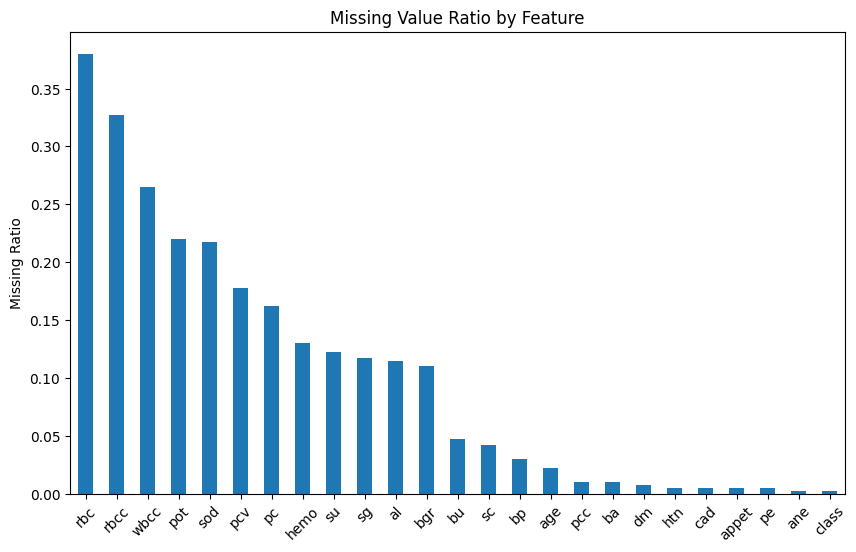

In [181]:
missing_ratio = df.isnull().mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
missing_ratio.plot(kind='bar')
plt.title('Missing Value Ratio by Feature')
plt.ylabel('Missing Ratio')
plt.xticks(rotation=45)
plt.show()

- 欠損値分布
  - rbc：約38%
  - rbcc / wbcc：25〜33%
  - pot / sod / pcv：15〜22%
- 解釈
  - 欠損は一部の変数に集中している、特に血液系（rbc, rbcc, wbcc）に偏り
  - 意味としてはデータ収集の偏り or 医療プロセスの影響？つまり「全員に測定されていない」、「特定条件でしか測っていない」

In [182]:
# 欠損 × class の関係を見る
df.groupby('class').apply(lambda x: x.isnull().mean())

/tmp/ipykernel_24360/974872468.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('class').apply(lambda x: x.isnull().mean())


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
class,,,,,,,,,,,,,,,,,,,,,,,,,
0.0,0.006711,0.013423,0.033557,0.033557,0.033557,0.060403,0.060403,0.026846,0.026846,0.040268,0.040268,0.033557,0.033557,0.033557,0.040268,0.026846,0.04698,0.04698,0.013423,0.013423,0.013423,0.006711,0.006711,0.006711,0.0
1.0,0.032000,0.040000,0.168000,0.164000,0.176000,0.572000,0.224000,0.000000,0.000000,0.152000,0.052000,0.048000,0.328000,0.332000,0.184000,0.268000,0.39600,0.49600,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0


- 欠損 × class の解釈
  - CKD（class=1）
    - rbc：57%
    - rbcc：49%
    - wbcc：39%
    - pcv：26%
  - 非CKD（class=0）
    - ほぼ0〜6%

欠損が明確にCKDに偏っている、欠損はランダムではない、「欠損が特徴量になっている」

### ヒストグラム

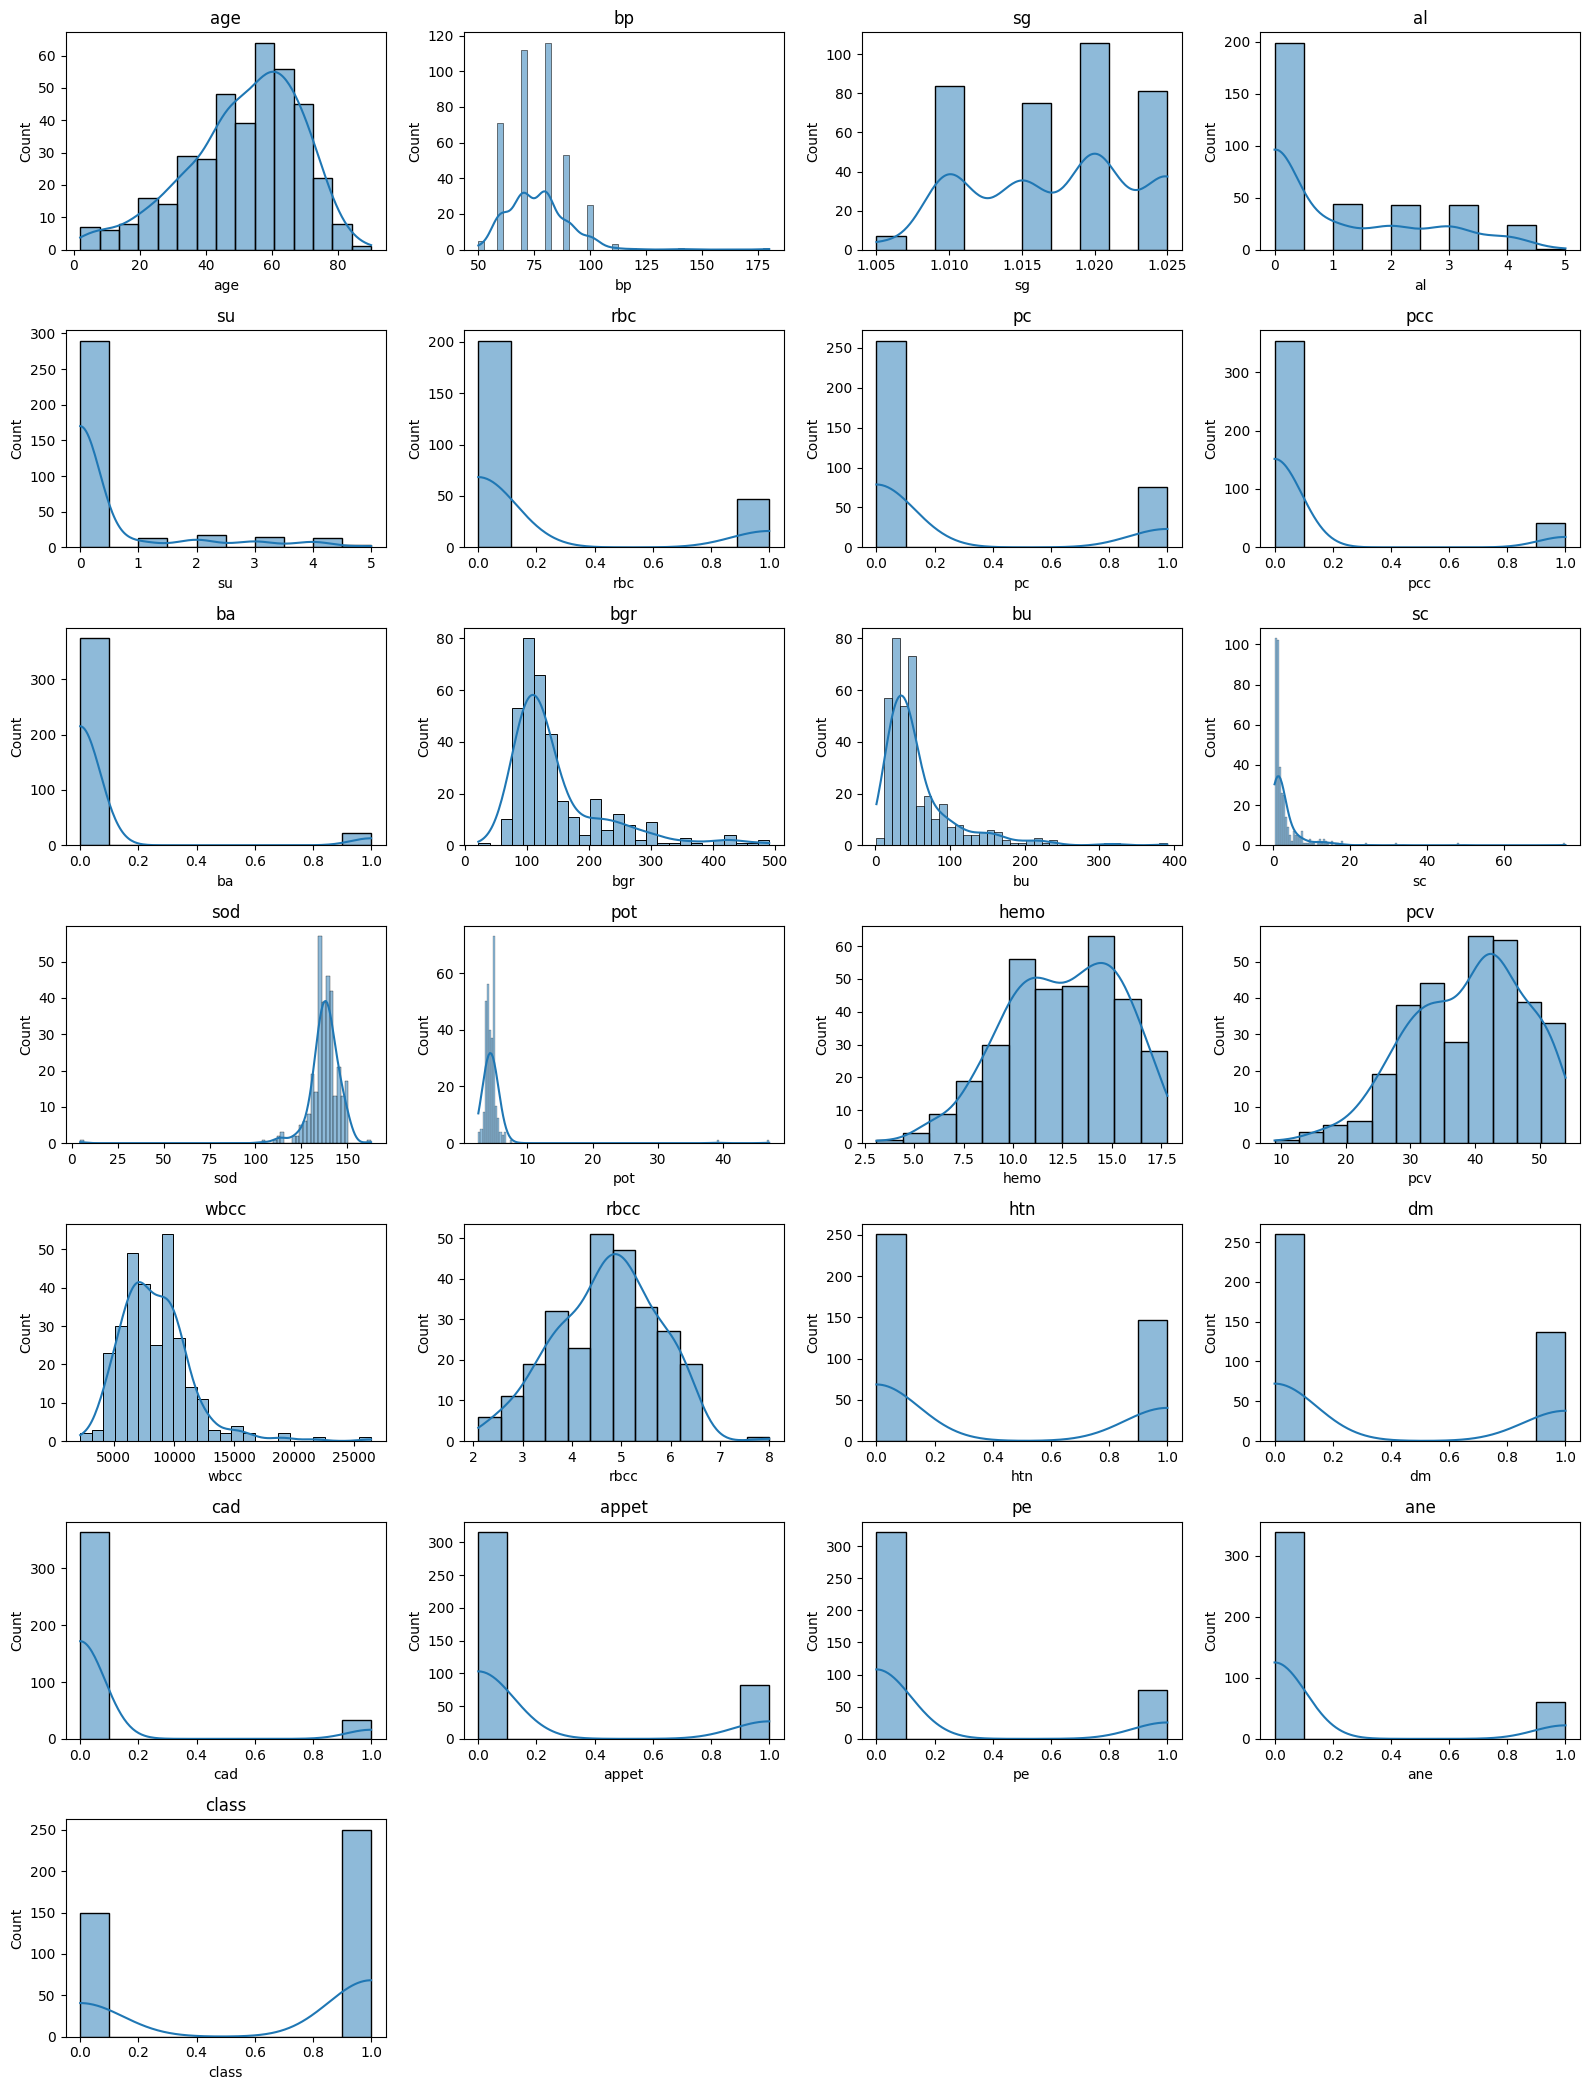

In [183]:
# 数値カラムを自動取得
num_cols = df.select_dtypes(include='number').columns

# 列数（固定）
n_cols = 4
# 行数（自動計算）
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(4*n_cols, 3*n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

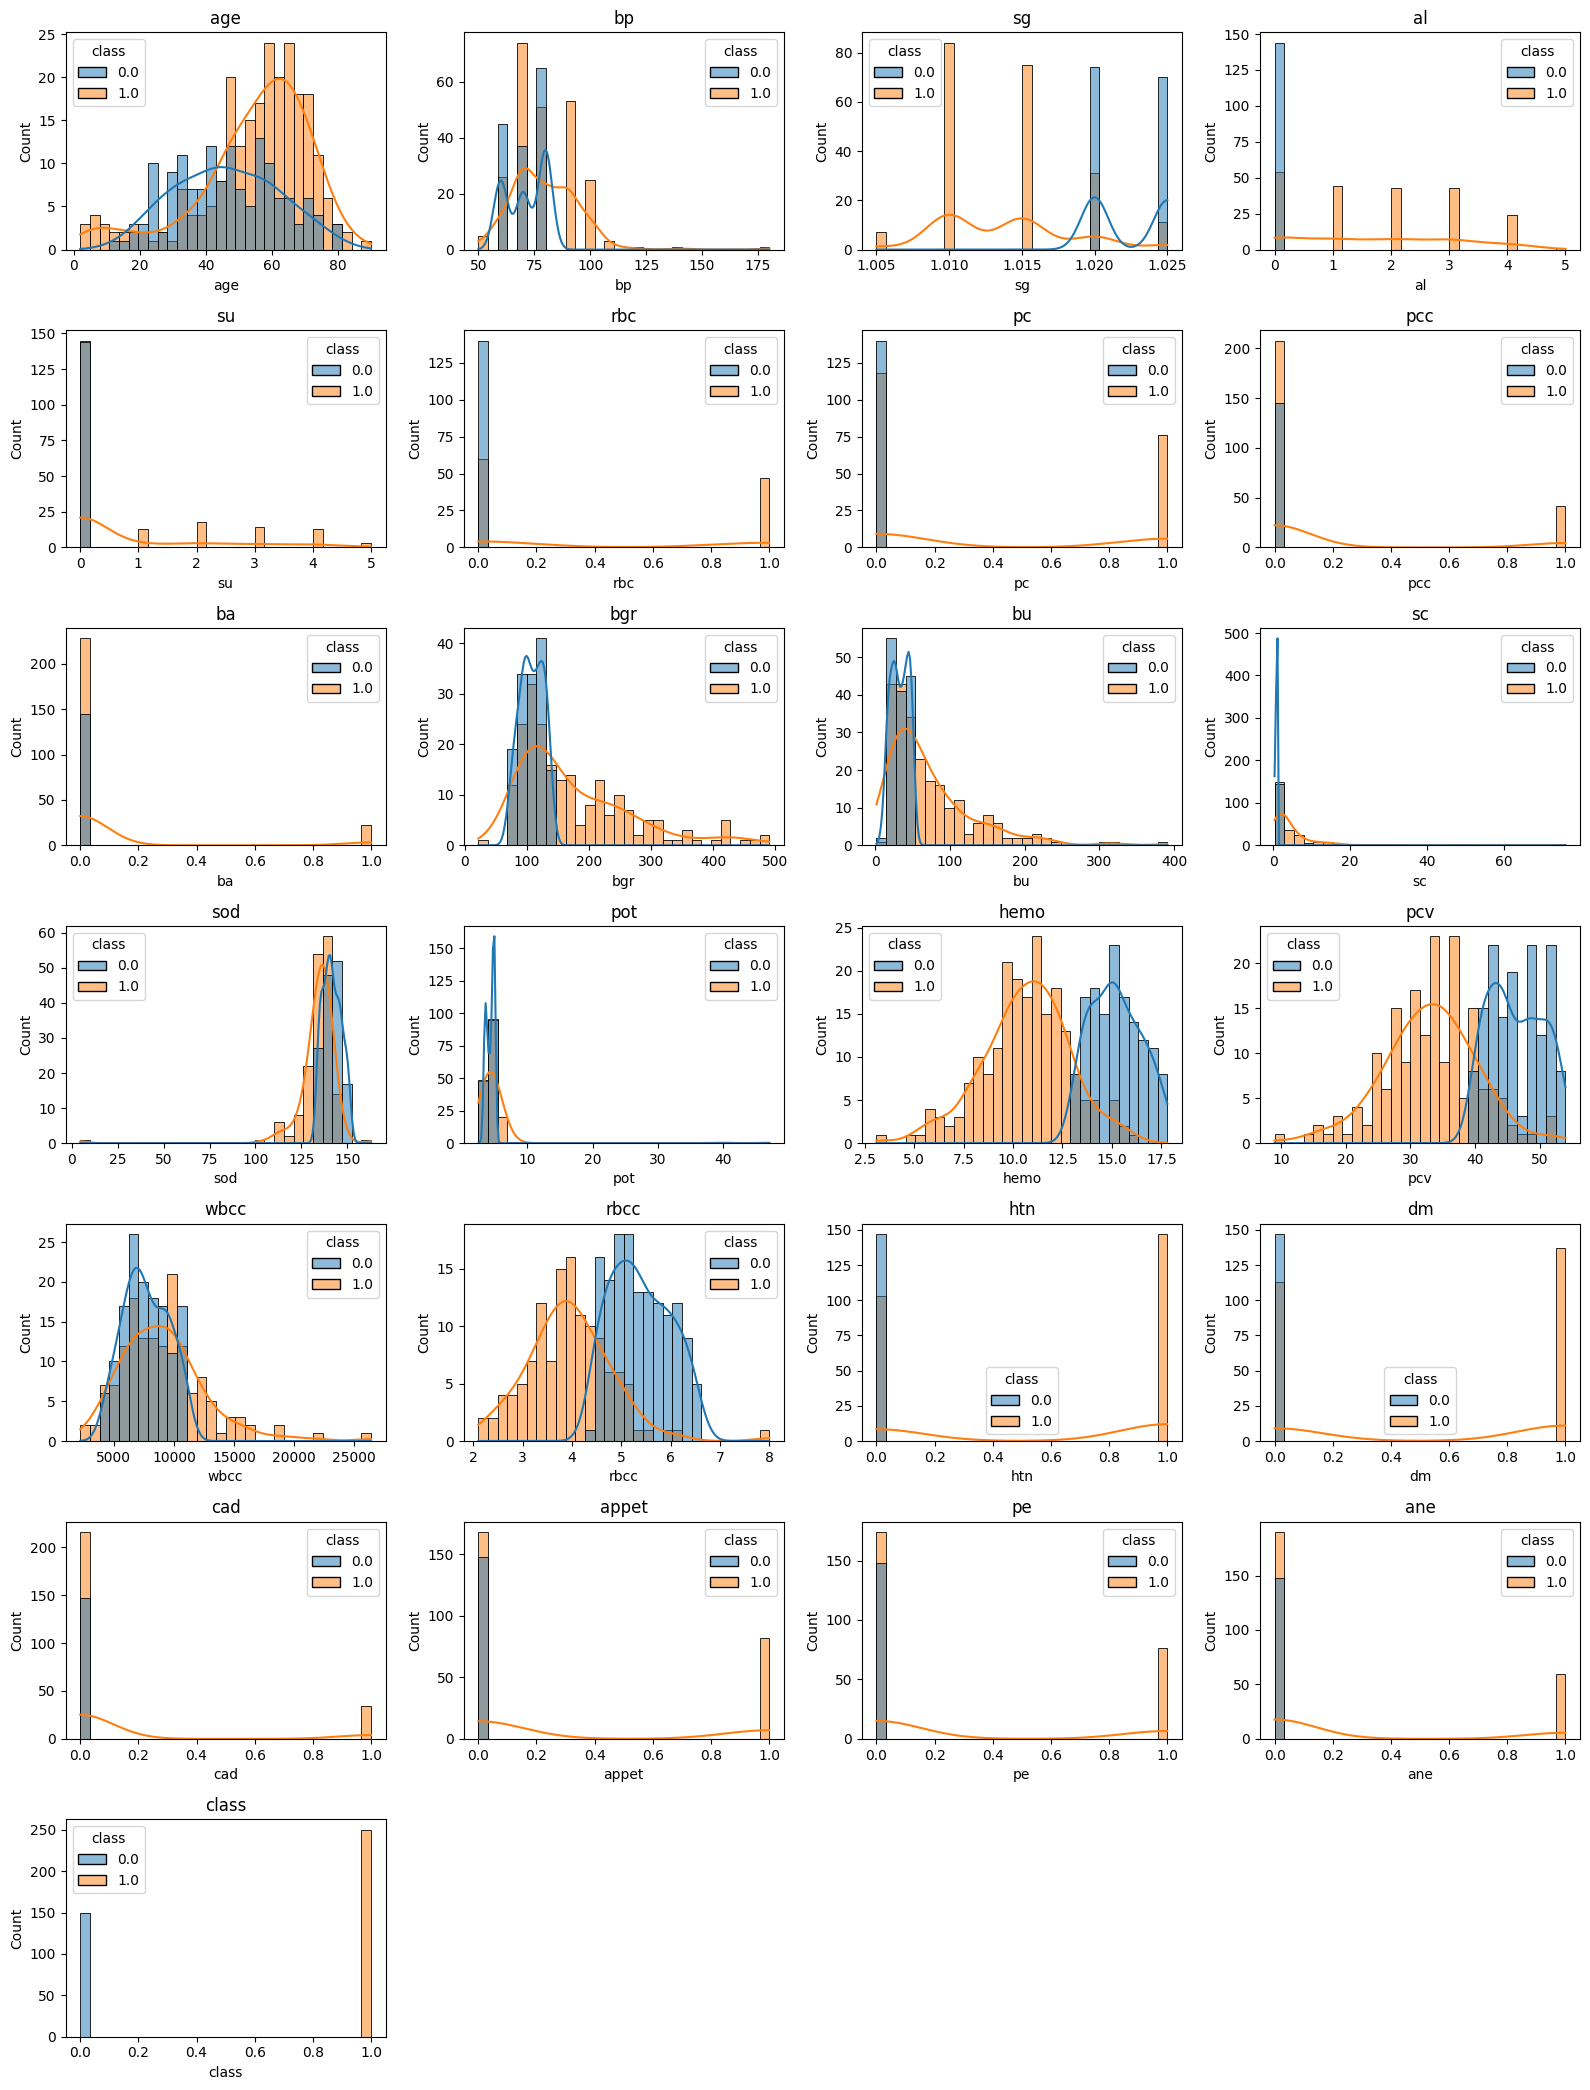

In [184]:
plt.figure(figsize=(4*n_cols, 3*n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(data=df, x=col, hue='class', kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

### 相関分析

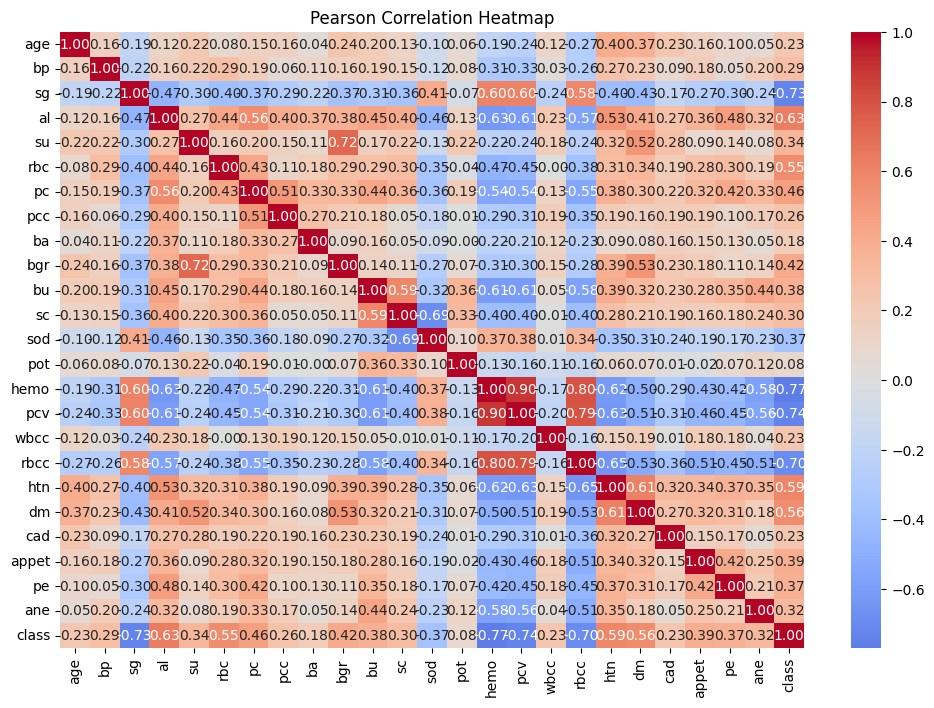

In [185]:
corr_pearson = df.corr(method='pearson')

plt.figure(figsize=(12,8))
sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Pearson Correlation Heatmap')
plt.show()

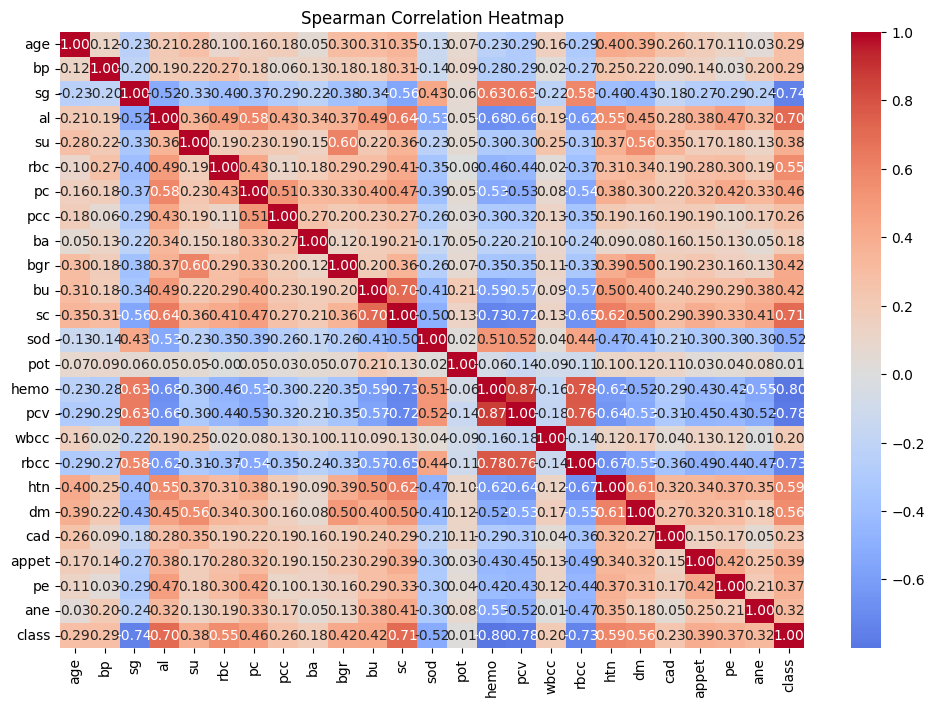

In [186]:
corr_spearman = df.corr(method='spearman')

plt.figure(figsize=(12,8))
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Spearman Correlation Heatmap')
plt.show()

- classとの相関
  - 正の相関（CKDで上がる）
    - sc（クレアチニン） ↑
    - bu（尿素） ↑
    - bgr（血糖） ↑
    - dm（糖尿病） ↑
    - htn（高血圧） ↑
      - 腎機能低下・代謝異常・高血圧がCKDと関連
    - al（尿中アルブミン） ↑
      - CKD → 糸球体障害 → タンパクが漏れる → 尿アルブミン↑

  - 負の相関（CKDで下がる）
    - hemo（ヘモグロビン） ↓
    - pcv（ヘマトクリット） ↓
    - rbcc（赤血球） ↓
      - 貧血（腎性貧血）がCKDと関連
    - sg（尿比重） ↓
      - CKD -> 尿濃縮力低下 -> 比重が下がる

- 解釈
  - 腎機能系
    - sc（クレアチニン）
      - CKD（オレンジ）が明らかに右側
      - CKDでクレアチニンが上昇 -> 腎機能低下
    - bu（尿素）
      - CKDで高値にシフト
      - 腎機能悪化を反映
  - 貧血
    - hemo
      - CKD（オレンジ）が左にズレている
      - CKDでヘモグロビン低下 → 腎性貧血
    - pcv / rbcc
      - 同様にCKDで低下
  - 尿検査
    - al（アルブミン）
      - CKD側に高値が多い
      - 蛋白尿（腎障害）
    - sg（尿比重）
      - CKDで低い方向に分布
      - 尿濃縮力低下（腎機能低下）
  - 代謝系
    - bgr（血糖）
      - CKDで高い値が多い
      - 外れ値あり
      - 糖代謝異常（糖尿病関連）
    - dm（糖尿病）
      - CKDで1が多い
      - 糖尿病はCKDのリスク因子
  - 血圧
    - bp / htn
      - CKDで高い傾向
      - 高血圧がCKDと関連

### 重要変数の箱ひげ図＆boxplot

#### 数値型変数の箱ひげ図

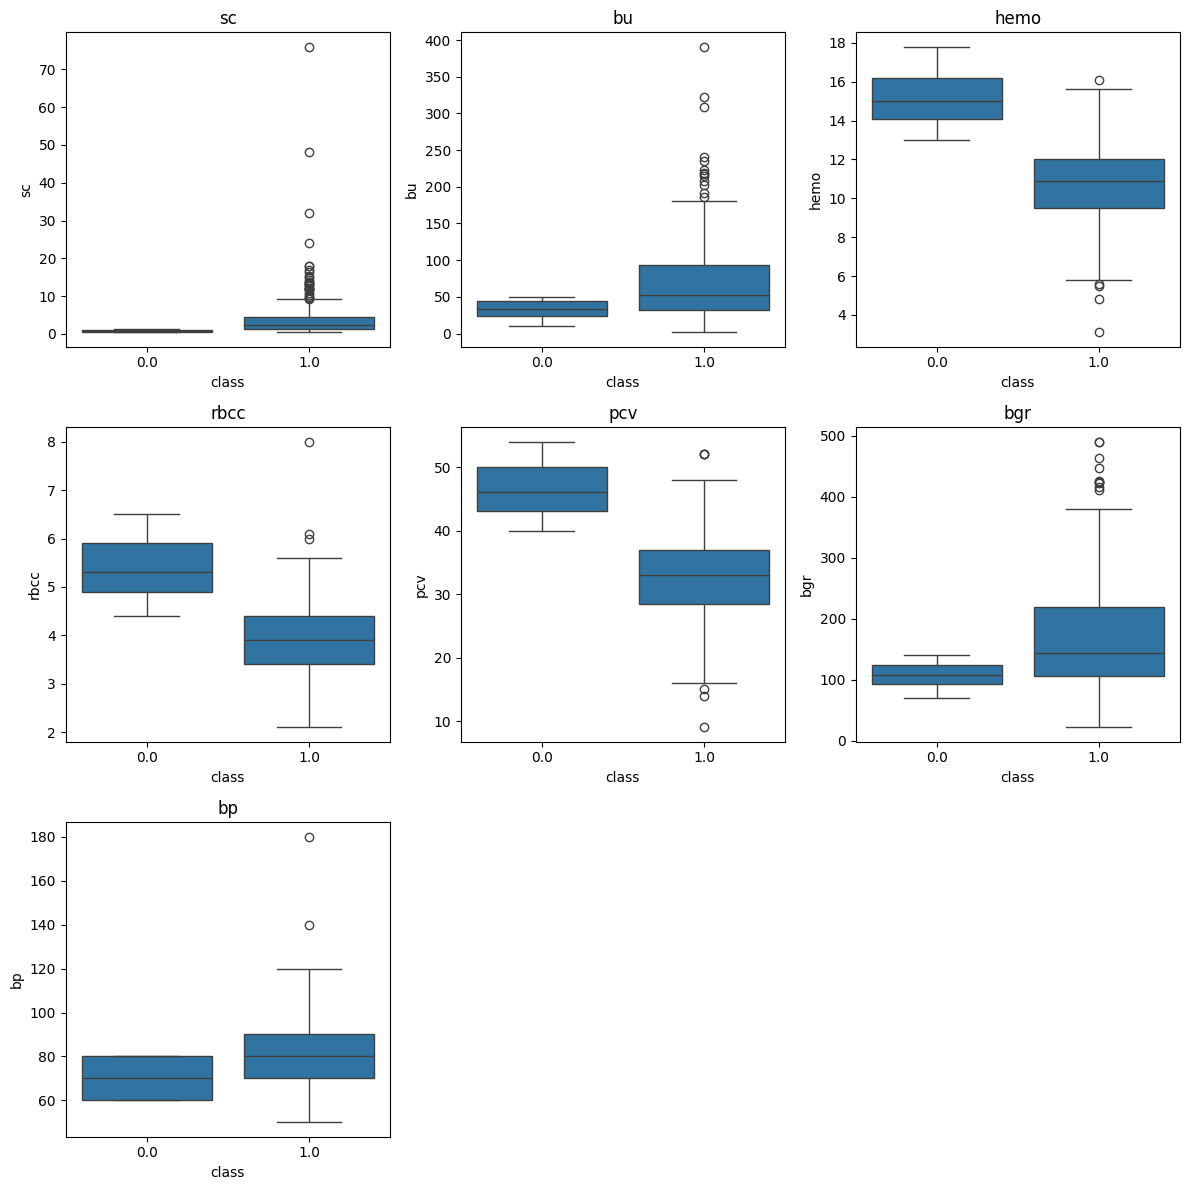

In [187]:
cols = ['sc','bu','hemo','rbcc','pcv','bgr','bp']

n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(12, 4 * n_rows))

for i, col in enumerate(cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x='class', y=col, data=df)
    plt.title(col)

plt.tight_layout()
plt.show()

- 重要変数の箱ひげ図の解釈
  - sc（クレアチニン）
    - CKD（class=1）で明らかに高い
    - 中央値が大きく上昇
    - 外れ値も多い（重症例）
    - 腎機能低下を反映
  - bu（尿素）
    - CKDで上昇
    - 腎機能低下を反映する
  - hemo（ヘモグロビン）
    - CKDで明確に低い
    - 腎性貧血が強く出ている
  - rbcc / pcv
    - CKDで低下
    - hemoと同じグループ
    - 貧血系はまとめて効いている（多重共線性注意）
  - bgr（血糖）
    - CKDで高い＋外れ値多い
    - 糖尿病の影響あり
  - bp（血圧）
    - CKDで少し高い
    - 差はあるが弱い？

#### カテゴリ型変数のboxplot

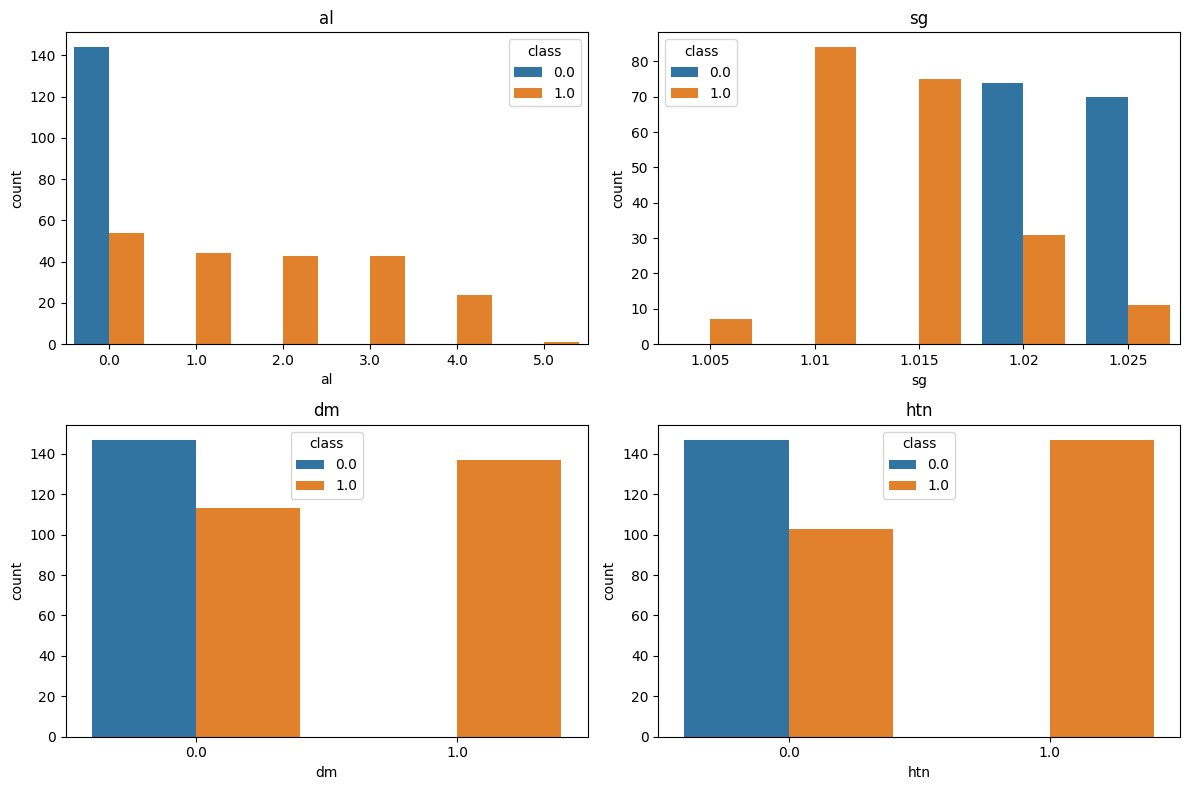

In [188]:
ord_cols = ['al','sg','dm','htn']

n_cols = 2
n_rows = math.ceil(len(ord_cols) / n_cols)

plt.figure(figsize=(12, 4 * n_rows))

for i, col in enumerate(ord_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(data=df, x=col, hue='class')
    plt.title(col)

plt.tight_layout()
plt.show()

- 重要変数boxplotの解釈
  - dm（糖尿病）
    - dm=1 -> CKDがかなり多い
    - dm=0 -> CKDと非CKDが混在
      - 糖尿病は強いリスク因子
  - htn（高血圧）
    - htn=1 -> ほぼCKD
    - htn=0 -> CKD割合低い
      - 高血圧は強いリスク因子
  - al（アルブミン）
    - class=0（非CKD） -> ほぼ 0に集中
    - class=1（CKD） -> 1〜4に広く分布
      - CKDで明らかに上昇、al ↑ = 蛋白尿
  - sg（尿比重）
    - class=0 → 1.020〜1.025に集中
    - class=1 → 1.010〜1.015に集中
      - CKDで低下、原因 = 尿濃縮力低下
  


### 仮説1：加齢の影響

<Axes: xlabel='class', ylabel='age'>

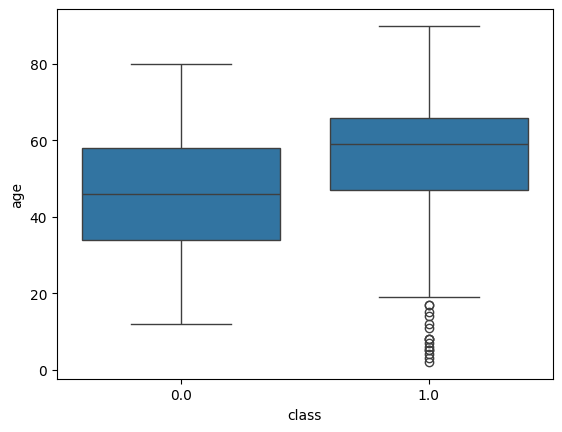

In [189]:
sns.boxplot(x='class', y='age', data=df)

<Axes: xlabel='age', ylabel='Count'>

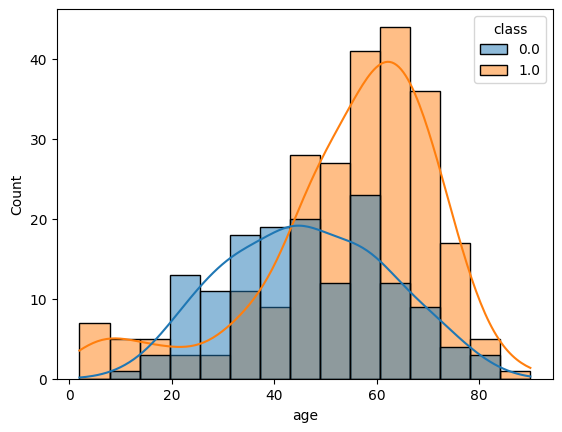

In [190]:
sns.histplot(data=df, x='age', hue='class', kde=True)

- 箱ひげ図＆boxplotの解釈
  - CKDで右にシフト（高齢）
  - 若年CKDも一定数いる
  - 分布は完全には分離しない
    - 年齢はリスク因子だが単独では弱い？

  

### 仮説2：dm vs htn

<Axes: xlabel='dm', ylabel='count'>

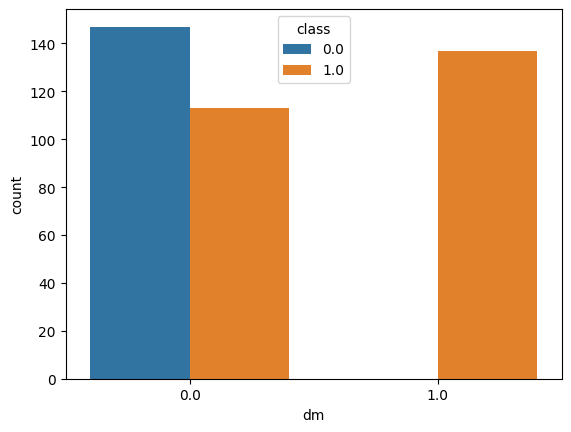

In [191]:
sns.countplot(data=df, x='dm', hue='class')

<Axes: xlabel='htn', ylabel='count'>

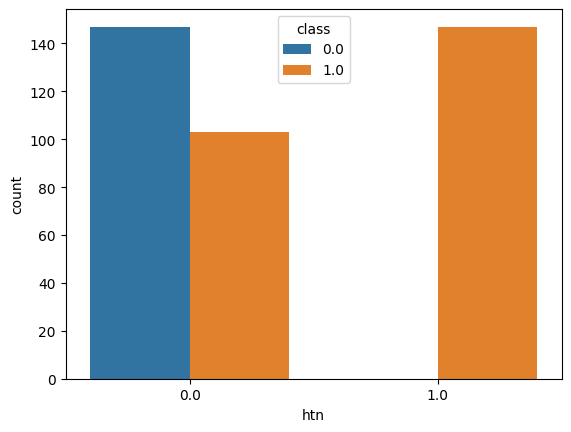

In [192]:
sns.countplot(data=df, x='htn', hue='class')

In [193]:
pd.crosstab(df['dm'], df['class'], normalize='index')

class,0.0,1.0
dm,,
0.0,0.565385,0.434615
1.0,0.000000,1.000000


- dm=0 -> CKD割合：約43%
- dm=1 -> CKD割合：100%

- 解釈
  - 糖尿病がある人は全員CKD
  - ただし糖尿病がない人でもCKDは結構いる（43%）

In [194]:
pd.crosstab(df['htn'], df['class'], normalize='index')

class,0.0,1.0
htn,,
0.0,0.588,0.412
1.0,0.000,1.000


- htn=0 -> CKD割合：約41%
- htn=1 -> CKD割合：100%

- 解釈
  - 高血圧あり → 全員CKD
  - 高血圧なしでもCKDはいるがdmよりは割合は低い（41%）

### 仮説3：若年CKD

In [195]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 40, 60, 100],
    labels=['young', 'middle', 'old']
)

In [196]:
all_cols = df.select_dtypes(include='number').columns.drop('class')

summary_age_class = (
    df.groupby(['age_group', 'class'])[all_cols]
      .mean()
      .round(2)
)

pd.set_option('display.max_columns', None)
summary_age_class

/tmp/ipykernel_24360/3142133222.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['age_group', 'class'])[all_cols]


age     bp    sg    al    su   rbc    pc   pcc    ba  \
age_group class                                                           
young     0.0    29.72  71.35  1.02  0.00  0.00  0.00  0.00  0.00  0.00   
          1.0    22.24  70.97  1.01  1.62  0.35  0.53  0.22  0.05  0.05   
middle    0.0    50.09  72.12  1.02  0.00  0.00  0.00  0.00  0.00  0.00   
          1.0    52.42  83.80  1.01  1.85  0.68  0.45  0.48  0.16  0.10   
old       0.0    68.75  69.29  1.02  0.00  0.00  0.00  0.00  0.00  0.00   
          1.0    68.54  78.51  1.01  1.62  1.05  0.36  0.37  0.23  0.10   

                    bgr     bu    sc     sod   pot   hemo    pcv     wbcc  \
age_group class                                                             
young     0.0    104.98  31.92  0.85  141.44  4.36  14.99  46.40  7481.25   
          1.0    126.17  57.35  3.32  134.86  4.11  11.24  35.77  8117.39   
middle    0.0    110.83  31.77  0.92  141.67  4.40  15.22  46.29  7823.08   
          1.0    183.73  79.56  5.09  131.76  4.98  10.30  31.80  9418.75   
old       0.0    105.65  35.88  0.78  142.41  4.16  15.49  46.11  7696.43   
          1.0    181.84  70.15  4.15  135.53  5.06  10.89  33.44  9093.44   

                 rbcc   htn    dm   cad  appet    pe   ane  
age_group class                                             
young     0.0    5.42  0.00  0.00  0.00   0.00  0.00  0.00  
          1.0    4.20  0.18  0.21  0.00   0.26  0.32  0.18  
middle    0.0    5.42  0.00  0.00  0.00   0.00  0.00  0.00  
          1.0    3.76  0.59  0.54  0.11   0.36  0.31  0.32  
old       0.0    5.25  0.00  0.00  0.00   0.00  0.00  0.00  
          1.0    4.09  0.73  0.68  0.22   0.34  0.30  0.17

In [197]:
# 若年だけを抽出
df_young = df[df['age_group'] == 'young'].copy()

df_young.shape

(91, 26)

In [198]:
# 若年の class 数を確認
df_young['class'].value_counts()

,count
class,
0.0,53
1.0,38


In [199]:
# 若年における CKD / 非CKD の平均比較
young_summary = (
    df_young.groupby('class')[all_cols]
    .mean()
    .round(2)
)

young_summary

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane
class,,,,,,,,,,,,,,,,,,,,,,,,
0.0,29.72,71.35,1.02,0.00,0.00,0.00,0.00,0.00,0.00,104.98,31.92,0.85,141.44,4.36,14.99,46.40,7481.25,5.42,0.00,0.00,0.0,0.00,0.00,0.00
1.0,22.24,70.97,1.01,1.62,0.35,0.53,0.22,0.05,0.05,126.17,57.35,3.32,134.86,4.11,11.24,35.77,8117.39,4.20,0.18,0.21,0.0,0.26,0.32,0.18


- 若年CKDの特徴
  - 糖尿病の影響
    - bgr：104 -> 126（上昇）
    - dm：0 -> 0.21（21%）
      - 若年CKDでも糖尿病は関与しているが主因ではない（割合は低め）
  - 高血圧
    - htn：0 -> 0.18（18%）
    - bpは大きな差なし
      - 若年CKDは高血圧依存が弱い

**若年CKDは生活習慣病型ではないCKD？**

## 立てた仮説をブラッシュアップ

- 仮説①：加齢の影響(検定＋ロジスティック回帰)
  - 年齢はCKDと関連するか
  - 年齢は他の因子を調整しても独立して関連するか
- 仮説②：dm vs htn(ロジスティック回帰)
  - dmとhtnのどちらがCKDに強く関連するか
  - 年齢によってその影響は変わるか（交互作用）
- 仮説③：若年CKDの特徴(検定)
  - 若年層においてCKDと非CKDで差がある指標は何か

## 統計的仮説検定

### 仮説①：加齢の影響

- Mann-Whitney U検定（両側検定）(有意水準 α = 0.05)
  - 帰無仮説：CKD群と非CKD群の年齢の分布は同じ
  - 対立仮説：CKD群と非CKD群の年齢の分布は異なる

In [200]:
# class=0: 非CKD
age_non_ckd = df[df['class'] == 0]['age'].dropna()

# class=1: CKD
age_ckd = df[df['class'] == 1]['age'].dropna()

# Mann-Whitney U検定（両側検定）
stat, p_value = mannwhitneyu(
    age_non_ckd,
    age_ckd,
    alternative='two-sided'
)

print('非CKD n:', len(age_non_ckd))
print('CKD n:', len(age_ckd))
print('非CKD 中央値:', age_non_ckd.median())
print('CKD 中央値:', age_ckd.median())
print('U statistic:', stat)
print('p-value:', p_value)

非CKD n: 148
CKD n: 242
非CKD 中央値: 46.0
CKD 中央値: 59.0
U statistic: 11833.5
p-value: 1.8640987758619894e-08


In [201]:
if p_value < 0.05:
    print('有意差あり：CKD群と非CKD群で年齢分布に差がある')
else:
    print('有意差なし：CKD群と非CKD群で年齢分布に差があるとは言えない')

有意差あり：CKD群と非CKD群で年齢分布に差がある


Mann-Whitney U検定の結果、CKD群と非CKD群の年齢分布には有意差が認められた（p < 0.001）。
CKD群の年齢中央値は59歳、非CKD群は46歳であり、CKDは高齢者に多い傾向が示唆された。
ただし、年齢が他の因子（糖尿病・高血圧など）の影響を受けている可能性もあるため、今後は多変量解析により独立した影響を検討する必要がある。

### 仮説③：若年CKDの特徴

#### 数値変数（age, bp, bgr, bu, sc, sod, pot, hemo, pcv, wc, rc）

- Mann-Whitney U検定（両側検定）(有意水準 α = 0.05)
  - 帰無仮説：若年CKD群と非CKD群で、この変数の分布に差はない
  - 対立仮説：若年CKD群と非CKD群で、この変数の分布に差がある

In [202]:
# 若年層の抽出
df_young = df[df['age_group'] == 'young'].copy()

# class数の確認
print(df_young['class'].value_counts())

class
0.0    53
1.0    38
Name: count, dtype: int64


In [203]:
# 数値変数
numeric_cols = [
    'age', 'bp', 'bgr', 'bu', 'sc',
    'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc'
]

# カテゴリ変数
categorical_cols = [
    'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba',
    'htn', 'dm', 'cad', 'appet', 'pe', 'ane'
]

In [204]:
num_results = []

for col in numeric_cols:
    group0 = df_young[df_young['class'] == 0][col].dropna()
    group1 = df_young[df_young['class'] == 1][col].dropna()

    if len(group0) > 0 and len(group1) > 0:
        stat, p = mannwhitneyu(group0, group1, alternative='two-sided')

        num_results.append({
            'variable': col,
            'test': 'Mann-Whitney U',
            'non_CKD_n': len(group0),
            'CKD_n': len(group1),
            'non_CKD_median': group0.median(),
            'CKD_median': group1.median(),
            'p_value': p
        })

num_results_df = pd.DataFrame(num_results)
num_results_df.sort_values('p_value')

,variable,test,non_CKD_n,CKD_n,non_CKD_median,CKD_median,p_value
7,hemo,Mann-Whitney U,49,30,14.90,11.80,5.118525e-10
8,pcv,Mann-Whitney U,50,26,46.00,36.00,9.742708e-08
5,sod,Mann-Whitney U,52,22,142.00,136.00,1.527800e-04
4,sc,Mann-Whitney U,51,33,0.90,1.10,3.013100e-04
10,rbcc,Mann-Whitney U,48,11,5.30,3.90,2.209446e-03
0,age,Mann-Whitney U,53,38,30.00,22.50,1.783448e-02
6,pot,Mann-Whitney U,52,22,4.45,3.95,4.671774e-02
9,wbcc,Mann-Whitney U,48,23,7100.00,7700.00,4.171671e-01
3,bu,Mann-Whitney U,51,33,33.00,28.00,6.239467e-01
1,bp,Mann-Whitney U,52,31,70.00,70.00,7.046920e-01


#### カテゴリ変数（sg, al, su, rbc, pc, pcc, ba, htn, dm, cad, appet, pe, ane）

- カイ二乗検定 / Fisher検定
  - 帰無仮説：若年CKD群と非CKD群で、この変数の分布（割合）は同じ
  - 対立仮説：若年CKD群と非CKD群で、この変数の分布（割合）は異なる

In [205]:
cat_results = []

for col in categorical_cols:
    data = df_young[[col, 'class']].dropna()
    table = pd.crosstab(data[col], data['class'])

    if table.shape[0] > 1 and table.shape[1] == 2:
        # 期待度数を確認
        chi2, p_chi, dof, expected = chi2_contingency(table)

        # 2×2で期待度数が小さい場合はFisher
        if table.shape == (2, 2) and (expected < 5).any():
            oddsratio, p = fisher_exact(table)
            test_name = 'Fisher exact'
        else:
            p = p_chi
            test_name = 'Chi-square'

        cat_results.append({
            'variable': col,
            'test': test_name,
            'p_value': p,
            'dof': dof,
            'table': table
        })

cat_results_df = pd.DataFrame([
    {
        'variable': r['variable'],
        'test': r['test'],
        'p_value': r['p_value'],
        'dof': r['dof']
    }
    for r in cat_results
])

cat_results_df.sort_values('p_value')

,variable,test,p_value,dof
0,sg,Chi-square,2.291925e-11,4
1,al,Chi-square,1.317626e-08,4
3,rbc,Fisher exact,4.289591e-07,1
10,pe,Chi-square,4.568316e-05,1
9,appet,Fisher exact,7.355551e-05,1
8,dm,Fisher exact,5.754239e-04,1
4,pc,Fisher exact,7.431186e-04,1
7,htn,Fisher exact,1.559213e-03,1
11,ane,Fisher exact,1.559213e-03,1
2,su,Fisher exact,5.847176e-02,1


In [206]:
alpha = 0.05

num_sig = num_results_df[num_results_df['p_value'] < alpha].sort_values('p_value')
cat_sig = cat_results_df[cat_results_df['p_value'] < alpha].sort_values('p_value')

print("数値変数：有意差あり")
display(num_sig)

print("カテゴリ変数：有意差あり")
display(cat_sig)

数値変数：有意差あり


,variable,test,non_CKD_n,CKD_n,non_CKD_median,CKD_median,p_value
7,hemo,Mann-Whitney U,49,30,14.90,11.80,5.118525e-10
8,pcv,Mann-Whitney U,50,26,46.00,36.00,9.742708e-08
5,sod,Mann-Whitney U,52,22,142.00,136.00,1.527800e-04
4,sc,Mann-Whitney U,51,33,0.90,1.10,3.013100e-04
10,rbcc,Mann-Whitney U,48,11,5.30,3.90,2.209446e-03
0,age,Mann-Whitney U,53,38,30.00,22.50,1.783448e-02
6,pot,Mann-Whitney U,52,22,4.45,3.95,4.671774e-02


カテゴリ変数：有意差あり


,variable,test,p_value,dof
0,sg,Chi-square,2.291925e-11,4
1,al,Chi-square,1.317626e-08,4
3,rbc,Fisher exact,4.289591e-07,1
10,pe,Chi-square,4.568316e-05,1
9,appet,Fisher exact,7.355551e-05,1
8,dm,Fisher exact,5.754239e-04,1
4,pc,Fisher exact,7.431186e-04,1
7,htn,Fisher exact,1.559213e-03,1
11,ane,Fisher exact,1.559213e-03,1


若年層においてCKD群と非CKD群を比較した結果、腎機能低下指標や貧血指標、尿所見に加え、電解質異常や全身状態の指標にも有意差が認められた。
これらはCKDの進行に伴う所見であることから、若年CKDは必ずしも初期段階の軽症例ではなく、既に全身的影響を伴う進行例が一定数含まれている可能性がある。
また、糖尿病や高血圧といった生活習慣病の影響が相対的に小さいことを踏まえると、若年CKDは高齢者とは異なる病態背景を持つ可能性が示唆された。

## ロジスティック回帰のデータ前処理2

In [207]:
# データの確認
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        391 non-null    float64 
 1   bp         388 non-null    float64 
 2   sg         353 non-null    float64 
 3   al         354 non-null    float64 
 4   su         351 non-null    float64 
 5   rbc        248 non-null    float64 
 6   pc         335 non-null    float64 
 7   pcc        396 non-null    float64 
 8   ba         396 non-null    float64 
 9   bgr        356 non-null    float64 
 10  bu         381 non-null    float64 
 11  sc         383 non-null    float64 
 12  sod        313 non-null    float64 
 13  pot        312 non-null    float64 
 14  hemo       348 non-null    float64 
 15  pcv        329 non-null    float64 
 16  wbcc       294 non-null    float64 
 17  rbcc       269 non-null    float64 
 18  htn        398 non-null    float64 
 19  dm         397 non-null    fl

In [208]:
# age_group列を削除
df = df.drop(columns=['age_group'])

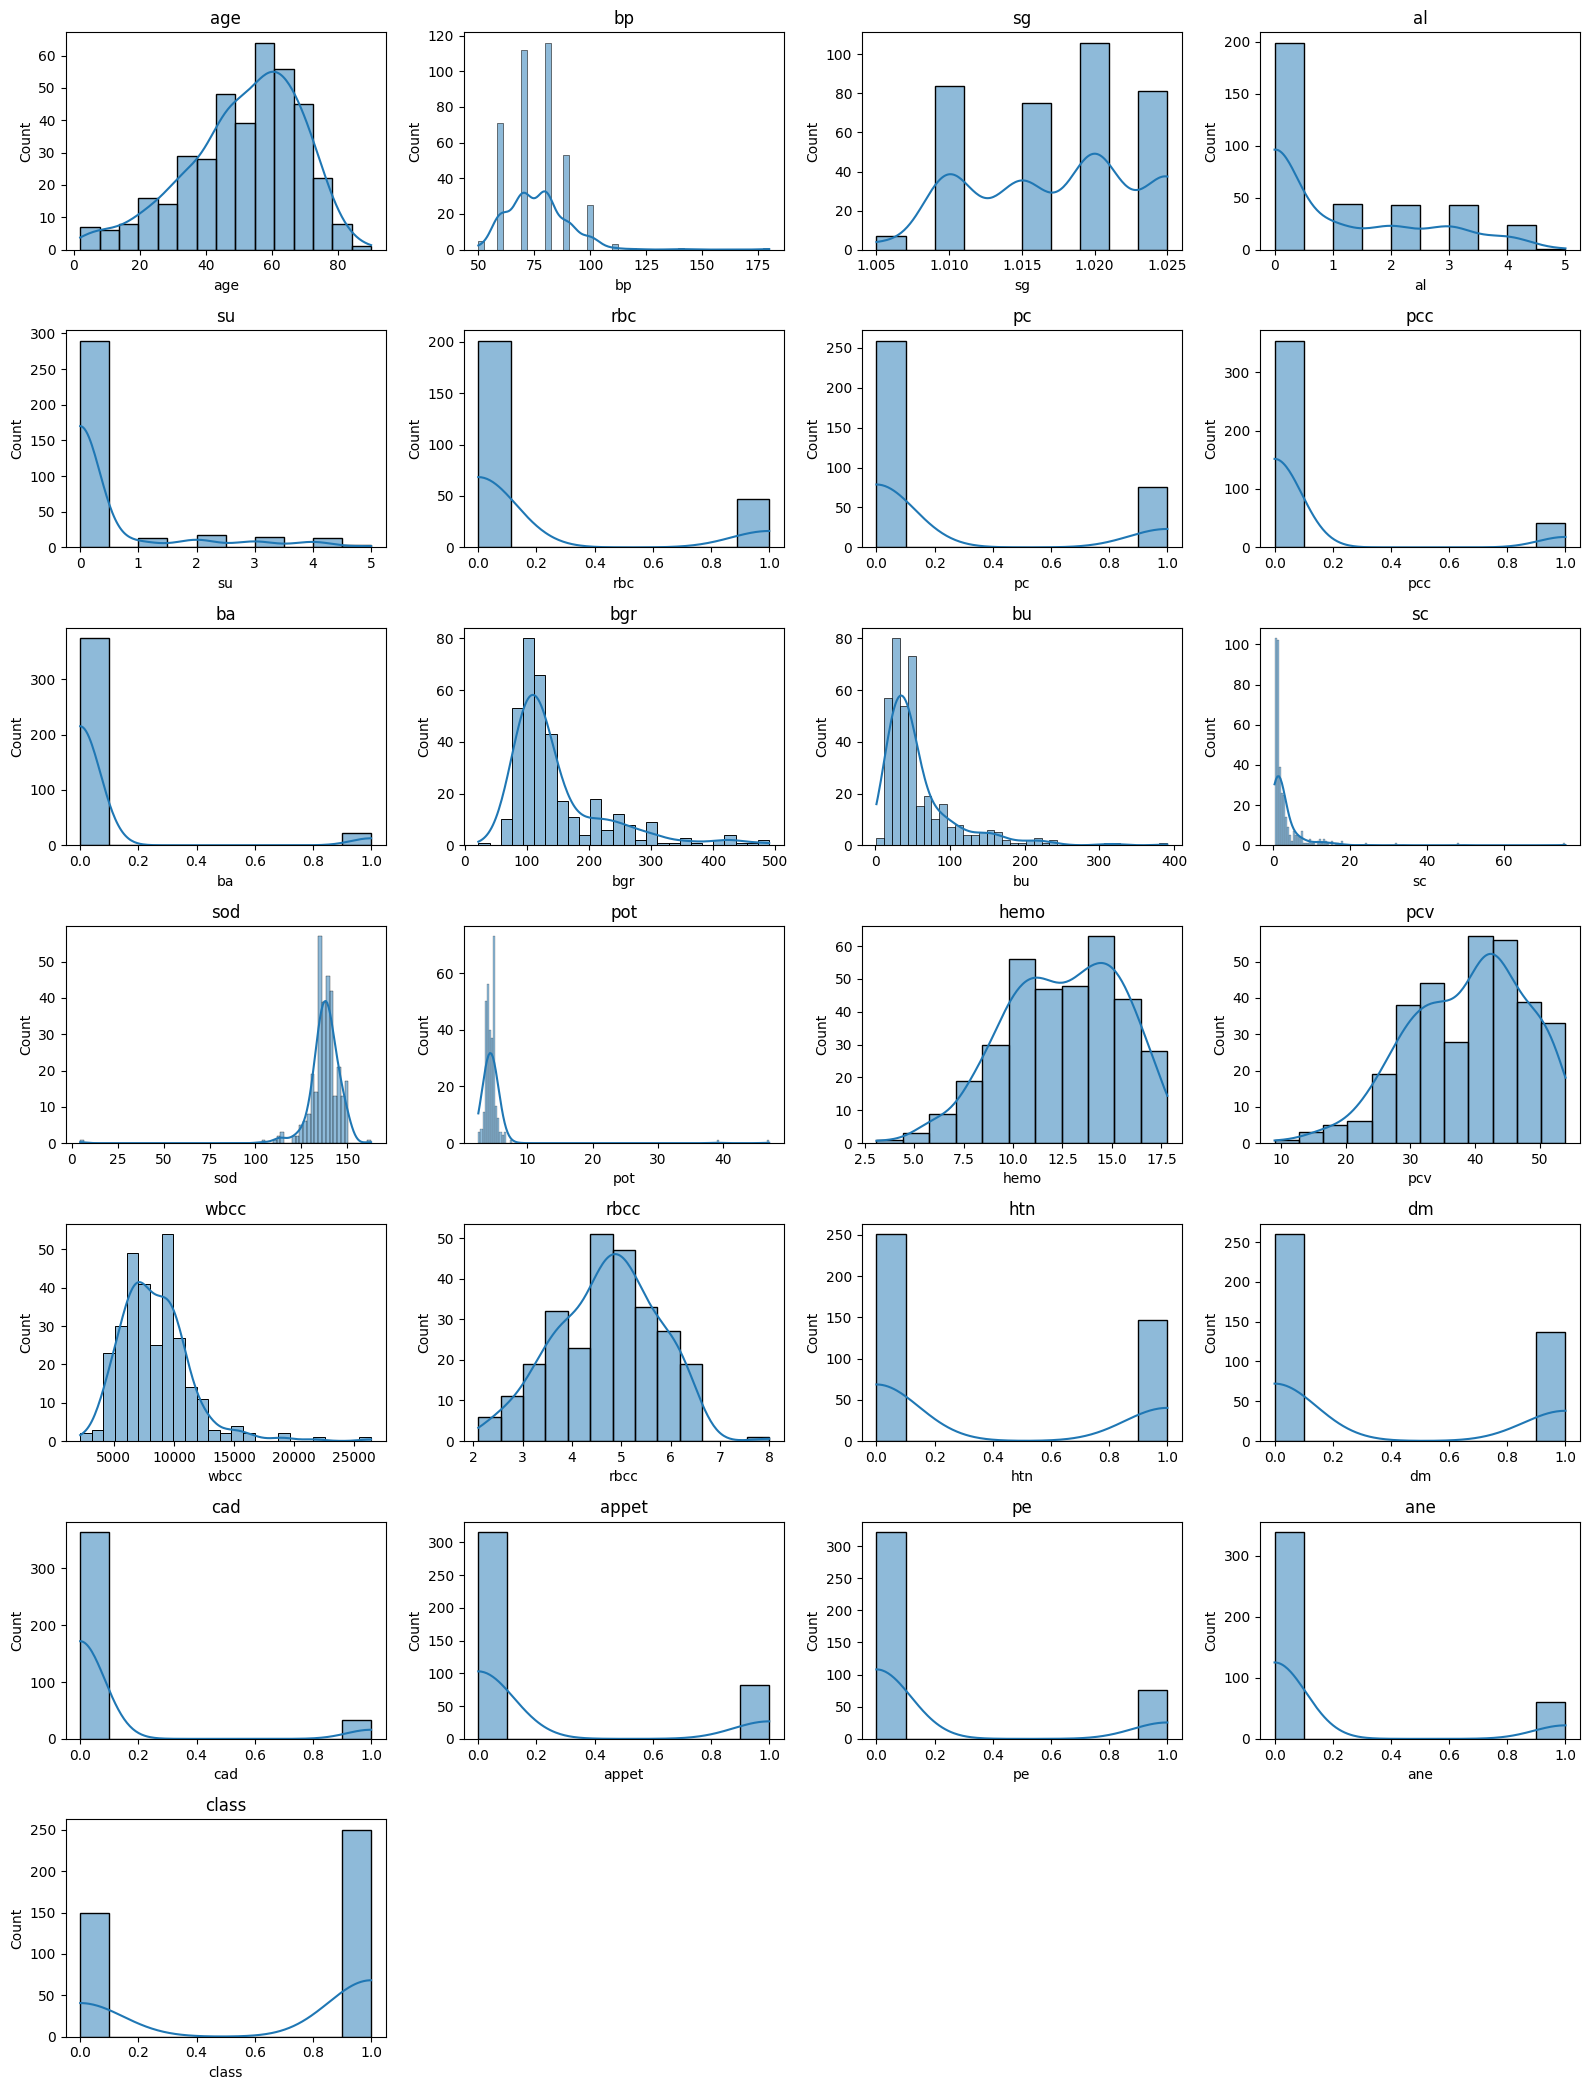

In [209]:
# 数値カラムを自動取得
num_cols = df.select_dtypes(include='number').columns

# 列数（固定）
n_cols = 4
# 行数（自動計算）
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(4*n_cols, 3*n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

In [210]:
# データ統計量の確認
df.describe()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
count,391.000000,388.000000,353.000000,354.000000,351.000000,248.000000,335.000000,396.000000,396.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,329.000000,294.000000,269.000000,398.000000,397.000000,398.000000,398.000000,398.000000,399.000000,399.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,0.189516,0.226866,0.106061,0.055556,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,38.884498,8406.122449,4.707435,0.369347,0.345088,0.085427,0.206030,0.190955,0.150376,0.626566
std,17.169714,13.683637,0.005717,1.352679,1.099191,0.392711,0.419431,0.308305,0.229351,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,8.990105,2944.474190,1.025323,0.483235,0.475997,0.279868,0.404961,0.393548,0.357888,0.484323
min,2.000000,50.000000,1.005000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,32.000000,6500.000000,3.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,40.000000,8000.000000,4.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,45.000000,9800.000000,5.400000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


- ['age','bp','bgr','bu','sc','sod','pot','hemo','pcv','wbcc','rbcc'] -> 数値型の連続値、非正規分布、外れ値がある。
  
  - -> 中央値で補完する。

- ['sg','al','su'] -> 順序あり、sgは(1.005,1.010,1.015,1.020,1.025)、alは(0,1,2,3,4,5)、suは(0,1,2,3,4,5)、以上の5分類

  - -> 中央値補完

- ['rbc','pc','pcc','ba','htn','dm','cad','appet','pe','ane'] -> (0/1)の二値分類

  - -> 最頻値補完

- ['rbc','rbcc','wbcc'] -> 欠損値が多い

  - ->「そのデータが欠損だったかどうか」を記録する列を追加する

In [211]:
# 欠損フラグ
for col in ['rbc','rbcc','wbcc']:
    df[f'{col}_missing'] = df[col].isna().astype(int)

# 数値
num_cols = ['age','bp','bgr','bu','sc','sod','pot','hemo','pcv','wbcc','rbcc']
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# 順序あり
ord_cols = ['sg','al','su']
df[ord_cols] = df[ord_cols].fillna(df[ord_cols].median())

# カテゴリ
cat_cols = ['rbc','pc','pcc','ba','htn','dm','cad','appet','pe','ane']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [212]:
# 欠損値補完の確認
df.isnull().sum()

,0
age,0
bp,0
sg,0
al,0
su,0
rbc,0
pc,0
pcc,0
ba,0
bgr,0


- [class]の欠損値 -> 削除（drop）を行う 1行削除

In [213]:
# classの欠損値は、その行ごと削除
df = df.dropna(subset=['class'])

## ロジスティック回帰

本課題では目的変数がCKDの有無という二値分類であるため、 連続値を予測する重回帰分析ではなく、 確率として解釈可能なロジスティック回帰を採用しました。

ロジスティック回帰では出力が0〜1の確率として得られ、 医療分野においてリスク評価として解釈しやすい点も適していると考えたため。

さらに、ロジスティック回帰は係数をオッズ比として解釈できるため、 どの特徴量がどの程度CKDリスクに影響を与えるかを 説明可能なモデルとして有用であると考えた。

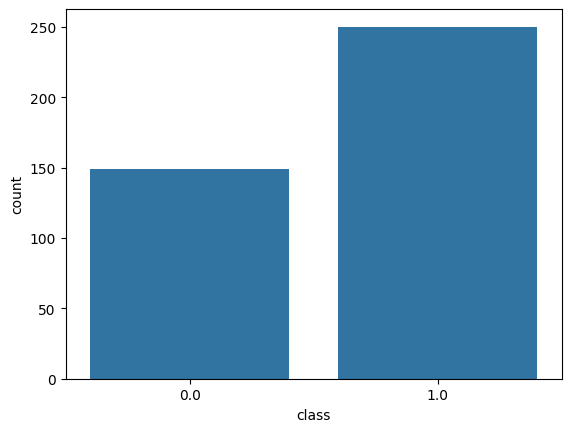

In [214]:
# classの割合、不均衡気味だが問題なし
sns.countplot(x="class", data=df);

### 目的変数と説明変数の切り離し

In [215]:
# 目的変数と説明変数
X = df.drop(columns=['class'])
y = df['class']

### データの標準化

In [216]:
# 連続値の変数（標準化する）
num_cols = [
    'age','bp','bgr','bu','sc','sod','pot',
    'hemo','pcv','wbcc','rbcc'
]

# それ以外（そのまま）
cat_cols = [col for col in X.columns if col not in num_cols]

- 0/1（二値）
- カテゴリ（one-hot後）

**上記の説明変数は標準化しない**

In [217]:
# 分割
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 分離
X_train_num = X_train[num_cols]
X_test_num = X_test[num_cols]

X_train_cat = X_train[cat_cols]
X_test_cat = X_test[cat_cols]

# 標準化
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

# DataFrame化
X_train_num_scaled = pd.DataFrame(X_train_num_scaled, columns=num_cols, index=X_train.index)
X_test_num_scaled = pd.DataFrame(X_test_num_scaled, columns=num_cols, index=X_test.index)

# 結合
X_train_processed = pd.concat([X_train_num_scaled, X_train_cat], axis=1)
X_test_processed = pd.concat([X_test_num_scaled, X_test_cat], axis=1)

### モデルの学習

In [218]:
# ロジスティック回帰モデルの学習
model = LogisticRegression(
    max_iter=1000,
    random_state=0
)

model.fit(X_train_processed, y_train)

LogisticRegression(max_iter=1000, random_state=0)

In [219]:
# 予測
y_pred = model.predict(X_test_processed)

# CKDである確率
y_proba = model.predict_proba(X_test_processed)[:, 1]

### モデルの評価

In [220]:
# 評価
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 0.9875
Precision: 1.0
Recall: 0.98
F1: 0.98989898989899
ROC-AUC: 0.9986666666666667

Confusion Matrix
[[30  0]
 [ 1 49]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98        30
         1.0       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



#### 混同行列

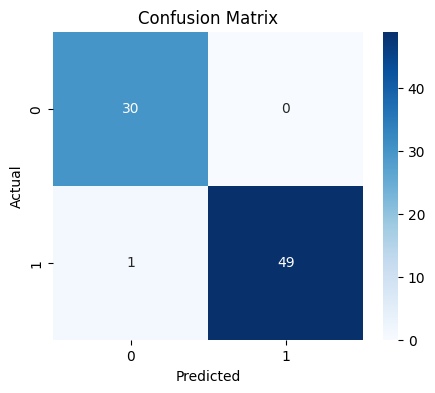

              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98        30
         1.0       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



In [221]:
# 混同行列
cm = confusion_matrix(y_test, y_pred)

# ヒートマップで可視化
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# 詳細指標
print(classification_report(y_test, y_pred))

- 混同行列
  - TN(True Negative)
    - 30
  - FP(False Positive)
    - 0
  - FN(False Negative)
    - 1
  - TP(True Positive)
    - 49

#### Precision / Recall / F1 Score

In [222]:
# Precision / Recall / F1 Score
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).T

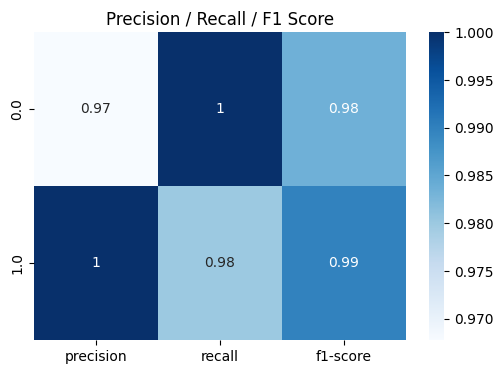

In [223]:
# ヒートマップで可視化
plt.figure(figsize=(6,4))

sns.heatmap(
    report_df.loc[['0.0', '1.0'], ['precision', 'recall', 'f1-score']],
    annot=True,
    cmap='Blues'
)

plt.title('Precision / Recall / F1 Score')
plt.show()

混同行列より、本モデルはCKD患者の見逃し（FN）が1件と極めて少なく、Recallは0.98と高い値を示した。 また、CKDと予測した症例はすべて正しく、Precisionは1.00であった。 このことから、本モデルはCKD検出において非常に高い性能を有し、臨床的にも有用であると考えられる。

#### ROC曲線、AUC

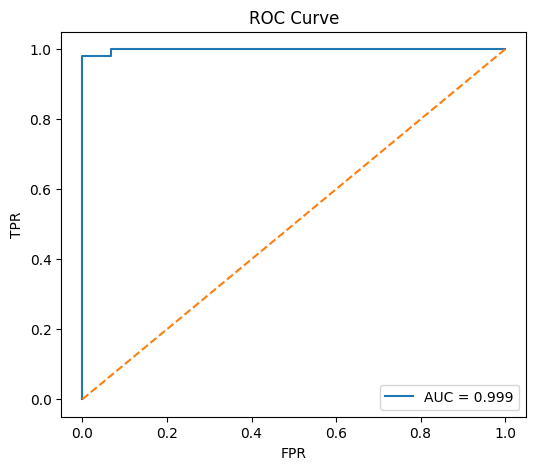

In [224]:
# ROC曲線、AUC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

- ROC曲線、AUC
  - AUC = 0.999
    - ROC曲線は左上に近いほど分類性能が高い。本モデルではAUCが0.999と非常に高く、CKD群と非CKD群をほぼ正確に識別できている。一方で、サンプル数が約400件と少なく、テストデータも80件であるため、AUCが非常に高い点については過学習やデータセット特性の影響も考慮する必要がある。本モデルは高い識別性能を示したが、実運用では単にAUCを見るだけでなく、CKDの見逃しを避けるためRecallを重視し、分類閾値の調整も検討する。

### 閾値調整

- 閾値調整
  - 通常、ロジスティック回帰は0.5を閾値として分類するが、この値は問題に応じて最適とは限らない。CKDの見逃し（False Negative）を防ぐため、Recallを重視する必要がある。

In [225]:
# 閾値適正化
y_proba = model.predict_proba(X_test_processed)[:, 1]

In [226]:
threshold = 0.3

y_pred_custom = (y_proba >= threshold).astype(int)

In [227]:
print("Precision:", precision_score(y_test, y_pred_custom))
print("Recall:", recall_score(y_test, y_pred_custom))
print("F1:", f1_score(y_test, y_pred_custom))

Precision: 0.98
Recall: 0.98
F1: 0.98


In [228]:
thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for th in thresholds:
    y_pred_th = (y_proba >= th).astype(int)

    results.append([
        th,
        precision_score(y_test, y_pred_th),
        recall_score(y_test, y_pred_th),
        f1_score(y_test, y_pred_th)
    ])

df_th = pd.DataFrame(results, columns=["threshold", "precision", "recall", "f1"])
df_th

,threshold,precision,recall,f1
0,0.10,0.961538,1.00,0.980392
1,0.15,0.961538,1.00,0.980392
2,0.20,0.960784,0.98,0.970297
3,0.25,0.980000,0.98,0.980000
4,0.30,0.980000,0.98,0.980000
5,0.35,1.000000,0.98,0.989899
6,0.40,1.000000,0.98,0.989899
7,0.45,1.000000,0.98,0.989899
8,0.50,1.000000,0.98,0.989899
9,0.55,1.000000,0.98,0.989899


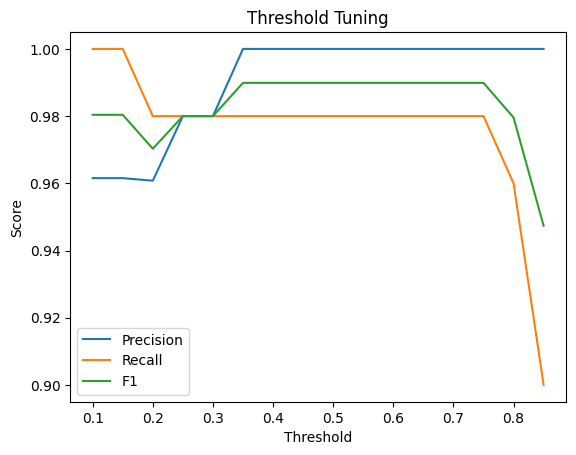

In [229]:
plt.plot(df_th["threshold"], df_th["precision"], label="Precision")
plt.plot(df_th["threshold"], df_th["recall"], label="Recall")
plt.plot(df_th["threshold"], df_th["f1"], label="F1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Threshold Tuning")
plt.show()

閾値調整によりPrecisionとRecallのトレードオフを確認した。

本モデルでは0.3〜0.7の範囲でF1スコアが高く安定していましたが、医療領域では見逃し（False Negative）が重大なリスクとなるため、Recallを優先し、閾値は0.2〜0.3付近が適切と判断した。この設定により誤検出（False Positive）は増加しますが、
スクリーニング用途としては許容可能と考えている。

- 適切な閾値
  - threshold = 0.2〜0.3
    - 理由：Recall ≈ 1.0 を維持

### オッズ比

In [230]:
coef_df = pd.DataFrame({
    "feature": X_train_processed.columns,
    "coefficient": model.coef_[0],
    "odds_ratio": np.exp(model.coef_[0])
})

coef_df = coef_df.sort_values("odds_ratio", ascending=False)
coef_df

,feature,coefficient,odds_ratio
24,rbc_missing,2.178890,8.836496
12,al,1.234477,3.436580
18,htn,1.031159,2.804314
14,rbc,1.023570,2.783112
4,sc,0.948955,2.583009
19,dm,0.920349,2.510166
25,rbcc_missing,0.897698,2.453947
13,su,0.775920,2.172590
2,bgr,0.679963,1.973805
1,bp,0.670516,1.955246


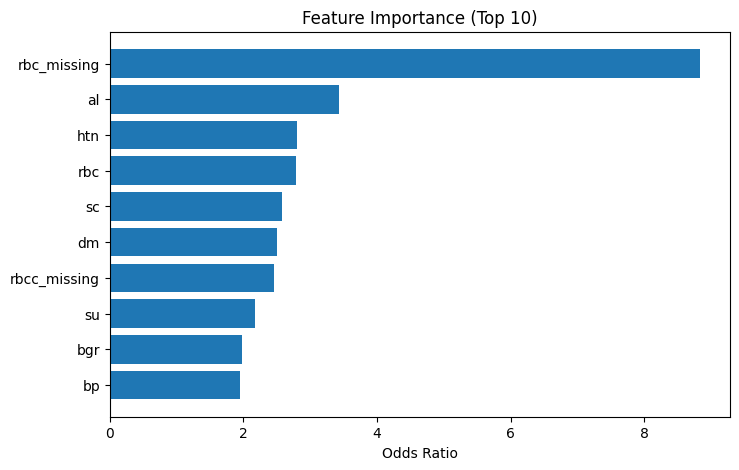

In [231]:
top_features = coef_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features["feature"], top_features["odds_ratio"])
plt.gca().invert_yaxis()
plt.xlabel("Odds Ratio")
plt.title("Feature Importance (Top 10)")
plt.show()

- ロジスティック回帰のオッズ比

  - rbc_missing
    - 最も強いが「原因ではなく結果に近い」
      - 赤血球異常（貧血）はCKDでよく起こる
      - 腎臓が悪くなる -> 赤血球産生低下
      - 診断的には強いが、予防には使いにくい
  - al
    - 栄養状態 or 慢性炎症の指標
      - 低アルブミン -> 体調悪化・慢性疾患
      - CKD患者でよく低下 -> タンパク尿
      - 予防・介入可能な重要因子
  - htn
    - CKDの原因として王道
      - 高血圧 -> 腎臓の血管ダメージ
      - 長期で腎機能低下
  - rbc / rbcc_missing
    - 血液異常（これも結果寄り）
  - sc（クレアチニン）
    - 腎機能そのもの
      - ほぼ「診断指標」
  - dm（糖尿病）
    - CKDの二大原因の一つ
  - su（尿中糖）
  - bgr（血糖）
    - 高血糖状態
  - bp（血圧）
    - htnと同じ文脈

## 仮説の再確認

- 仮説①：加齢の影響(検定＋ロジスティック回帰)
  - 年齢はCKDと関連するか -> Yes(検定で実証)
  - 年齢は他の因子を調整しても独立して関連するか -> No(多変量では弱い)

    - ロジスティック回帰(オッズ比)
      - age のオッズ比 ≈ 0.91
      - 係数：負
        - 年齢は独立したリスク因子としては弱い

**年齢はCKDと関連するが、腎機能や貧血指標を調整すると独立した影響は小さくなると考えられる。**

- 仮説②：dm vs htn(ロジスティック回帰)
  - dmとhtnのどちらがCKDに強く関連するか -> htn（高血圧）の方がやや強い
  - 年齢によってその影響は変わるか（交互作用） -> 現時点では未検証

- 仮説②の結果
| 変数  | OR       |
| --- | -------- |
| htn | **2.80** |
| dm  | **2.51** |

  - htn（高血圧）の方がやや強い
  - 差はそこまで大きくない（ほぼ同等）

**糖尿病と高血圧はいずれもCKDと関連しており、やや高血圧の影響が強い傾向が見られた。**

- 仮説③：若年CKDの特徴(検定)
  - 若年層においてCKDと非CKDで差がある指標は何か -> 若年CKDは生活習慣病よりも、腎機能低下や貧血などの臓器機能異常が特徴として強く表れている可能性がある。**若年CKDは生活習慣病型ではないCKD？**(EDAと検定で実証)

## 交互作用

In [232]:
# 交互作用項の作成
df['age_dm'] = df['age'] * df['dm']
df['age_htn'] = df['age'] * df['htn']

In [233]:
# 説明変数
X = df.drop(columns=['class'])

# 目的変数
y = df['class']

# 標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# モデル
model = LogisticRegression(max_iter=1000)
model.fit(X_scaled, y)

LogisticRegression(max_iter=1000)

In [234]:
coef = model.coef_[0]
odds_ratio = np.exp(coef)

result = pd.DataFrame({
    'feature': X.columns,
    'coef': coef,
    'odds_ratio': odds_ratio
}).sort_values(by='odds_ratio', ascending=False)

result

,feature,coef,odds_ratio
24,rbc_missing,1.558721,4.752737
3,al,1.152692,3.166707
5,rbc,0.807678,2.242693
25,rbcc_missing,0.713549,2.041223
21,appet,0.681294,1.976434
11,sc,0.635221,1.887440
19,dm,0.555636,1.743050
22,pe,0.542115,1.719640
9,bgr,0.539972,1.715959
18,htn,0.520081,1.682164


- age_htnとage_dmの解釈
  - 両方とも OR > 1
  - 数値を見ると、age_htn：1.57、age_dm：1.52、「弱〜中程度の交互作用」

年齢と糖尿病・高血圧の交互作用項はいずれもオッズ比が1を上回っており、年齢の上昇とともにこれらのリスク因子の影響が増強される可能性が示唆された。ただし、その影響は中程度であり、強い交互作用とは言えない。

## 仮説の結論

- 仮説①：加齢の影響(検定＋ロジスティック回帰)
  - 年齢はCKDと関連するか -> Yes(検定で実証)
  - 年齢は他の因子を調整しても独立して関連するか -> No(多変量では弱い)

**年齢はCKDと有意に関連するが、腎機能や貧血指標を調整するとその影響は減弱し、これらを介した間接的な関連が示唆された。**

- 仮説②：dm vs htn(ロジスティック回帰)
  - dmとhtnのどちらがCKDに強く関連するか -> htn（高血圧）の方がやや強い(多変量で実証)
  - 年齢によってその影響は変わるか -> 年齢の上昇とともにこれらのリスク因子の影響が増強される可能性が示唆された。ただし、その影響は中程度であり、強い交互作用とは言えない。(交互作用で実証)

**糖尿病と高血圧はいずれもCKDと関連しており、オッズ比に大きな差はなく、両者が重要なリスク因子であると考えられる。また、交互作用の結果から、加齢に伴いこれらの影響が増強される傾向が示唆されたが、その影響は中程度であった。**

- 仮説③：若年CKDの特徴(検定)
  - 若年層においてCKDと非CKDで差がある指標は何か -> 若年CKDは生活習慣病よりも、腎機能低下や貧血などの臓器機能異常が特徴として強く表れている可能性がある。若年CKDは生活習慣病型ではないCKD？(EDAと検定で実証)

**若年層では糖尿病や高血圧との有意差は認められなかったが、関連がないと断定はできない。一方で、腎機能低下や貧血指標の異常が顕著であり、若年CKDでは臓器機能異常が特徴として強く現れる可能性がある。**